In [1191]:
import numpy as np

In [1192]:
# =========  1: The forward pass ===========
# 1.1 Linear layers
# A linear layer's weight matrix has size (output, input)
# 
# Per-neuron outputs per scalar j are ∑_i (w_j)_i * x_i + b_j, where i is the input dimension, and j is the output dimension
# Hence the j'th row of W corresponds to the vector w_j 
# All rows dot the same vector x
# -> Output of len j is the composition W @ x + b
# Simple as

class Layer(): 
    gr = "Not implemented" #debug
    def function(self):
        return NotImplementedError
    def grad(self, *args, **kwargs):
        return NotImplementedError
    def __call__(self, *args, **kwargs):
        return self.function(*args)
    def __repr__(self):
        return f"{self.name}"
    output = None
    input = None
    next = None 
    prev = None

class LinearLayer(Layer): 
    def function(self, x): 
        return x@self.weights.T+ self.biases #Numpy stores arrays as row vectors: (Wx.T).T = xW.T
    def __init__(self, input_size: int, output_size: int): 
        rng = np.random.default_rng()
        self.weights = rng.uniform(-1e-6, 1e-5, (output_size, input_size)) #Initialize with small uniform weights
        self.biases = rng.uniform(-1e-5, 1e-5, output_size)                # larger weights tend to break first few iterations on large matrices
        self.g_weights = np.zeros(self.weights.shape)
        self.g_biases = np.zeros(self.biases.shape)
    def size(self): 
        return f"{self.weights.shape[-1]}->{self.weights.shape[0]}"
    def __repr__(self):
        return(f"LinearLayer: {self.size()}")
    def grad(self, *args, **kwargs): 
        return self.weights.T



In [1328]:
# 1.2 Non-linear layers
# In a perceptron, we take a singular output w1x1 + w2x2 + ... wnxn, same as dot product w * x, 
# We "accept" if the sum exceeds some certain number, b, otherwise we reject. Mathematically equivalent to H(w*x + b)
# Piecewise cutoff is ill-conditioned, so we use smooth functions like the sigmoid
# Defining a few here, not sure what to use yet
# Gradient of most of these nonlinear layers are diagonal matrices, but softmax is a proper jacobian

class Nonlinear(Layer):
    name = "nonlinear"

# Making logvar from arbitrary linear combinations would maybe be a bit easier if we use 
# this layer, limiting positive values and keeping negatives prety similar
class LimitPositives(Layer):
    def __init__(self):
        self.name = "limit_positives"
        self.function = lambda z: np.where(z>0, np.log(np.maximum(z, 1e-8)), z)
        self.grad = lambda z: np.where(z>0, 1/z, 1)
        
class Sigmoid(Nonlinear):
    def __init__(self): 
        self.function = lambda z: (1+np.exp(-z))**-1
        self.grad = lambda z: self.function(z)*(1-self.function(z))
        self.name = "sigmoid"

class ReLU(Nonlinear):
    def __init__(self):
        self.function = lambda z: np.maximum(0, z)
        self.grad = lambda z: np.where(z > 0, 1,0)
        self.name = "relu"






# Softmax is useful for turning the final layer output into a probability distribution
# I think encoder image reconstruction doesn't necesarilly use it since it's not a classifier, 
# but I'll make it just in case I need it later 

class Softmax(Nonlinear):
    def __init__(self): 
        self.name = "softmax"
        self.function = lambda z: np.exp(z - np.max(z)) / np.sum(np.exp(z - np.max(z)))
    # diagonal entries are (y_1)(1-y_1) and off-diagonal entries are -y_i*y_j, where y_i = exp(x_i).
    # The (i,j)'th entry is y_i {i=j} - y_i*y_j => diag(y) - yy^T
    def grad(self, z):
        y = self.function(z)
        return (np.diag(y) - np.outer(y, y))


In [1194]:
# 1.2 combining layers to make neural networks
# the neural network links together the layers, and gives layers references to their inputs and outputs

class NeuralNetwork: 
    def __init__(self): 
        self.linear_layers = []
        self.first_module = None
        self.last_module = None
    def add(self, module): 
        if self.first_module is None: 
            self.first_module = module
        else: 
            module.prev = self.last_module
            self.last_module.next = module
        self.last_module = module
        if isinstance(module, LinearLayer):
            self.input_dim = module.weights.shape[0] if not self.first_module else None
            self.output_dim = module.weights.shape[-1]
            self.linear_layers.append(module)
    def forward(self, input):
        current_module = self.first_module
        input = tuple(np.atleast_2d(x) for x in input) if isinstance(input, tuple) else np.atleast_2d(input)  
        # treat as (batch, dim), single examples become batch=1
        current_module.input = input #(batch, dim)
        output = input
        while current_module:
            current_module.input = output
            if isinstance(output, tuple):
                batch_out = current_module(*output)
            else:
                batch_out = current_module(output)
            current_module.output = batch_out
            output = batch_out
            current_module = current_module.next
        return output
    def __repr__(self):
        current = self.first_module
        while current: 
            print(f"{current}")
            current = current.next

In [1195]:
# =========  2: Using gradients to update the weights in neural networks ===========
# We initialize our neural network with random weights and biases for the linear layers. 
# If we put in an input, the output is probably wrong in most cases. 
# By quantifying how wrong an output is with a single scalar C (cost), hypothetically we could 
# find dCdP for any parameter P in the model as long as we could find some relation between C and L

class LossFunction(): 
    def __call__(self, *args, **kwargs):
        return self.function(*args, **kwargs)
    def function(self, *args, **kwargs): 
        raise NotImplementedError
    def grad(self, *args, **kwargs):
        raise NotImplementedError

# MSE was the original loss function created here, but could execerbate small gradients 
# from the origination point of the loss function, since on MNIST all loss values are 
# between 0 and 1, squaring them and dividing makes them even smaller. 
class L2(LossFunction):
    def function(self, x, ref): 
        batch_size = x.shape[0]
        return (np.sum((x-ref)**2)/2)/batch_size
    def grad(self, x, ref): 
        return (x-ref)



In [1196]:
# This functions similarly to a torch criterion, however that works
# It's based around how it's used on the surface and probably not similar to how it's implemented
#
# basics of backprop: 
# The model's final output is directly dependent on the last layer, 
# which itself is dependent on the prior layer, and so on. The neural network is a function composition of layers,
# so we can use the chain rule relating each layer to the previous one. 
# For the linear layers, z=Wx+b, we can find dzdW, and relate it back up to dCdW by multiplying by dCdz
#
# UNFORTUNATELY NumPy arrays are *row vectors*, meaning that for any batched matmul,
# If we do want to use softmax, there are now THREE different multiplications we can individually handle in the loop
#   a) Vectorized: hadamard, where (batch, dim) * (batch, dim) => (batch, dim): easy with * 
#   b) Weight matrices: regular matmul converted to denominator layout, where (dim2, dim1) * (batch, dim) => (batch, dim2)> with b @ A.T
#   c) Softmax: (batch, dim2, dim) @ (batch, dim) => (batch, dim2) where every vector in the batch gets its own matmul
# Do this with a custom case-by-case multiply function

class Loss:
    def __init__(self, model):
        self.model = model
        self.dCdzs = []
        self.xs = []
        self.grad = []
    def __call__(self, **loss_args):
        self.loss_args = loss_args
        self.output_loss = self.loss_fn(**self.loss_args)
    @staticmethod
    def _multiply_derivatives(a, b): 
        return a * b if a.shape == b.shape else b @ a.T

    # My OG VAE implementation used three seperate loss functions for the three
    # mu/l encoder + decoder neural networks, with manual backprop for the two-input
    # sampling layer. Not very efficient, so this function walks back all children, like a 
    # basic autograd on nodes, and stores derivatives locally
    
    def _back(self, module, dC): #dC is corresponding module.next.gr
        if isinstance(module, LinearLayer):
            x_ = module.input
            module.g_biases = np.mean(dC, axis=0)
            module.g_weights = (dC.T @ x_) / dC.shape[0]
        current_grad = module.grad(module.input)
        current_grad = current_grad if isinstance(current_grad, tuple) else (current_grad, )
        gr = [0]*len(current_grad)
        for index in range(len(gr)):
            gr[index] = self._multiply_derivatives(a=current_grad[index], b=dC)
        module.gr = gr if len(gr) > 1 else gr[0]
        if module.prev is not None:
            prev = module.prev if isinstance(module.prev, list) else [module.prev]
            for index, p in enumerate(prev):
                self._back(p, dC=gr[index])
    def backward(self):
        last = self.model.last_module #smth like sigmoid or softmax, y=σ(z)
        dCdy = self.loss_fn.grad(**self.loss_args)
        self._back(last, dCdy)


# === Individual loss functions 
# Maybe just make the loss class accept a loss function
class L2_loss(Loss):
    def __init__(self, model):
        super().__init__(model)
        self.loss_fn = L2()

In [1197]:
# =========  3: Defining optimizers operating on model parameters + grad ===========
# Torch stores gradients in the tensor objects, but mine are stored in LinearLayer.g_weights/biases
# Any optimizer can reuse the step method, the only difference between SGD/Adam is that prior to 
# stepping, they would update dW with whatever formula they do it with

class Optimizer:
    def _init_state(self, g): 
        raise NotImplementedError
    def _update(self, g): 
        raise NotImplementedError
    def __init__(self, linear_layers, lr): 
        self.lr = lr
        self.linear_layers = linear_layers
        self.stp = 0
        self.state = {} #state imitates NeuralNetwork.linear_layers 
    def _update(self, g):
        return g
    def step(self):
        self.grads = [{}]*len(self.linear_layers) #step tracks what is actually added
        for index, l in enumerate(self.linear_layers):
            dW = self.lr * self._update(l.g_weights, "weights", index, )
            db = self.lr * self._update(l.g_biases, "biases", index)
            self.grads[index]["weights"] = dW
            self.grads[index]["biases"] = db
            breakpoint()
            l.weights -= dW
            l.biases -= db
    
# 3.1 SGD, with momentum, uses a simple moving average of the two last gradients 
# (or just the current training example's gradient with no momentum), and it 
# steps with a fixed step size multiplier

class SGD(Optimizer):
    def __init__(self, linear_layers, lr, beta=0):
        super().__init__(linear_layers, lr)
        self.beta = beta
    def _init_state(self, linear_layers):
        return {
            "weights": [np.zeros_like(l.g_weights) for l in linear_layers],
            "biases": [np.zeros_like(l.g_biases) for l in linear_layers]
        }
    def _update(self, g, parameters, index):
        s = self.state[parameters][index]
        s = self.beta*s + (1-self.beta)*g
        return s
    def step(self):
        self.stp += 1
        self.state = self._init_state(self.linear_layers) if self.state == {} else self.state
        super().step()

# 3.2 ADAM optimizer
# With SGD, we are only approximating the first-order gradient, often badly
# So what use would approximating the parameters^2 terms for the second derivative? 
# Our sample gradients are from a distribution, and so if we can find the variance
#

class Adam(Optimizer): 
    def __init__(self, linear_layers, lr, b1=0.9, b2=0.999):
        super().__init__(linear_layers, lr)
        self.b1 = b1
        self.b2 = b2
    def _init_state(self, linear_layers):
        return {
            "m_W": [np.zeros_like(l.g_weights) for l in linear_layers],
            "m_b": [np.zeros_like(l.g_biases) for l in linear_layers],
            "v_W": [np.zeros_like(l.g_weights) for l in linear_layers],
            "v_b": [np.zeros_like(l.g_biases) for l in linear_layers]
        }
    def _update(self, g, parameters, index):
        s = self.state
        P = "W" if parameters == "weights" else "b"
        s[f"m_{P}"][index] = self.b1*s[f"m_{P}"][index] + (1-self.b1)*g
        s[f"v_{P}"][index] = self.b2*s[f"v_{P}"][index] + (1-self.b2)*(g**2)
        m_P_hat = s[f"m_{P}"][index] / (1-self.b1**self.stp) #Correction: grads start off really small
        v_P_hat = s[f"v_{P}"][index] / (1-self.b2**self.stp)
        return m_P_hat / (np.sqrt(v_P_hat)+1e-8)
    def step(self):
        self.stp += 1
        self.state = self._init_state(self.linear_layers) if self.state == {} else self.state
        super().step()
        

In [1198]:
# =========  4: Variational Autoencoder ==================================
# The VAE regularizes the latent space to a prior N(0,1 in order to make 
# arbitrary points in the latent dimension have meaning. It does this by 
# imposing a penalty between a sampled pre-decoder distribution and the prior
# using something like KL while balancing it with reconstruction error
#
# Our implementation consists of three distinct neural networks, one each for
# the mean/logvar encoder and one for the decoder. 

class Reparameterize(Layer):
    def __init__(self):
        self.name = "reparameterization trick"
        self.rng = np.random.default_rng()
    def function(self, mu, l):
        self.eps = self.rng.standard_normal(mu.shape)
        return mu + self.eps*np.exp(0.5*l)
    def grad(self, dist):
        mu, l = dist
        return (
            np.ones(mu.shape), #drdu
            0.5*self.eps*np.exp(0.5*l), #drdl
        )

class VariationalAutoencoder():
    def reparameterize(self, mu, l):
        self.eps = self.rng.standard_normal(mu.shape)
        return mu + self.eps*np.exp(0.5*l)
    def __init__(self):
        self.encoder_u = NeuralNetwork()
        self.encoder_l = NeuralNetwork()
        self.decoder = NeuralNetwork()
        self.rng = np.random.default_rng()
        # Although I couldn't design the forward pass to work based on two layers with one `next`, 
        # backprop works on one layer with multiple `prevs`
    def add(self, module, where):
        if where == "encoder_u":
            self.encoder_u.add(module)
        if where == "encoder_l":
            self.encoder_l.add(module)
        if where == "decoder":
            self.decoder.add(module)
            if module.prev is None:
                module.prev = [self.encoder_u.last_module, self.encoder_l.last_module]
    def forward(self, input):
        mu = self.encoder_u.forward(input)
        l = self.encoder_l.forward(input)
        # no_var = np.full(l.shape, -np.inf)
        y = self.decoder.forward((mu, l))
        return y, mu, l
    

In [1199]:
class VAE_loss(Loss):
    def loss_fn(self, **loss_args):
        outputs = self.loss_args.get("outputs")
        targets = self.loss_args.get("targets")
        recon_error = self.rc_loss_fn(outputs, targets)
        # mu = loss_args.get("mu")
        # l = loss_args.get("l")
        # latent_error = self.latent_loss_fn(mu, l)
        return recon_error
    def __init__(self, model, rc_loss_fn, latent_loss_fn, beta):
        super().__init__(model)
        self.rc_loss_fn = rc_loss_fn
        self.latent_loss_fn = latent_loss_fn   
        self.beta = beta   
    def backward(self):
        # Things would be a lot cleaner if my forward pass had linked nodes
        # a way that I *think* autograd is linked in (nodes), but then nodes
        # like Reparameterize() would have to wait for all their inputs
        encoder_u = self.model.encoder_u
        encoder_l = self.model.encoder_l
        decoder = self.model.decoder

        # === Terms dependent on reconstruction loss =======
        last = decoder.last_module
        outputs = self.loss_args.get("outputs")
        targets = self.loss_args.get("targets")
        dRCdy = self.rc_loss_fn.grad(outputs, targets)
        self._back(last, dRCdy)

        # === Terms dependent on KL loss =======





In [1200]:
v = VariationalAutoencoder()
v.add(LinearLayer(10,8), "encoder_u")
v.add(Sigmoid(), "encoder_u")
v.add(LinearLayer(10,8), "encoder_l")
v.add(Sigmoid(), "encoder_l")

v.add(Reparameterize(), "decoder")
v.add(LinearLayer(8,10), "decoder")
v.add(Sigmoid(), "decoder")

In [1201]:
input = np.ones((11,10))
output, mu, l = v.forward(input)
ref = np.zeros((11,10))

In [1202]:
vae_loss = VAE_loss(v, L2(), L2(), beta=0.1)
vae_loss(outputs=output, targets=ref)
print(vae_loss.output_loss)
vae_loss.backward()

1.2500240729529148


In [1203]:

vae_encoder_l = Adam(v.encoder_l.linear_layers, lr=0.1)
vae_encoder_l.step()

In [1204]:
new, _, __ = v.forward(input)
vae_loss(outputs=new, targets=ref)
print(vae_loss.output_loss)

1.2500277131611766


___

In [1205]:
# =========  5: Testing on MNIST ===========
from tensorflow.keras.datasets import mnist

(x_train, _), (x_test, _) = mnist.load_data()
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)


In [1410]:


autoencoder = VariationalAutoencoder()
autoencoder.add(LinearLayer(784, 128), "encoder_u")
autoencoder.add(Sigmoid(), "encoder_u")
autoencoder.add(LinearLayer(128, 16), "encoder_u")
autoencoder.add(Sigmoid(), "encoder_u")

autoencoder.add(LinearLayer(784, 128), "encoder_l")
autoencoder.add(Sigmoid(), "encoder_l")
autoencoder.add(LinearLayer(128, 16), "encoder_l")
autoencoder.add(LimitPositives(), "encoder_l")

autoencoder.add(Reparameterize(), "decoder")
autoencoder.add(LinearLayer(16, 128), "decoder")
autoencoder.add(Sigmoid(), "decoder")
autoencoder.add(LinearLayer(128, 784), "decoder")
autoencoder.add(Sigmoid(), "decoder")

losses = []
mus = []
logvars = []

In [1484]:
sample_ind = np.random.choice(x_train.shape[0], 240000, replace=True)
numbers = x_train[sample_ind]

from tqdm import tqdm
BATCH_SIZE = 24
LR = 0.001

loss = VAE_loss(autoencoder, L2(), L2(), beta=0.1)

decoder_opt = Adam(autoencoder.decoder.linear_layers, lr=LR)
encoder_u_opt = Adam(autoencoder.encoder_u.linear_layers, lr=LR*0.1)
encoder_l_opt = Adam(autoencoder.encoder_l.linear_layers, lr=LR*1000)
optimizers = [
    decoder_opt, encoder_u_opt, encoder_l_opt
]


In [1485]:
batch_loss = []
pbar = tqdm(enumerate(range(0, len(numbers), BATCH_SIZE)), 
            total=(len(numbers) + BATCH_SIZE - 1)//BATCH_SIZE,
            desc="Training...")

for batch_idx, i in pbar: #per-batch
    batch_numbers = numbers[i:i+BATCH_SIZE]
    y, mu, l = autoencoder.forward(batch_numbers)
    loss(outputs=y, targets=batch_numbers)
    batch_loss.append(loss.output_loss)
    loss.backward()

    for opt in optimizers:
        opt.step()

    if (batch_idx+1) % 100 == 0: #Save every 100 steps (batch_size*100 numbers)
        recent =  np.mean(batch_loss)
        losses.append(recent)
        mus.append(mu.mean())
        logvars.append(l.mean())
        batch_loss = []
        # Track the norms of a matrix that get added, this is saved in the optimizer class
        # I'm not sure how close this is to the implementation of grad_norm in torch trainers
        grad_to_track = optimizers[-1].grads[-1] #encoder_l, logvar (128->16) weights
        layer_to_track = optimizers[-1].linear_layers[-1]
        g_norm = np.linalg.norm(grad_to_track["weights"]) 
        w_norm = np.linalg.norm(layer_to_track.weights)
        pbar.set_postfix(mean_rc=f"{recent:.2f}", w_norm=f"{w_norm:.2e}", g_norm=f"{g_norm:.2e}")



Training...: 100%|██████████| 10000/10000 [04:59<00:00, 33.43it/s, g_norm=2.47e-03, mean_rc=9.14, w_norm=2.54e+01]


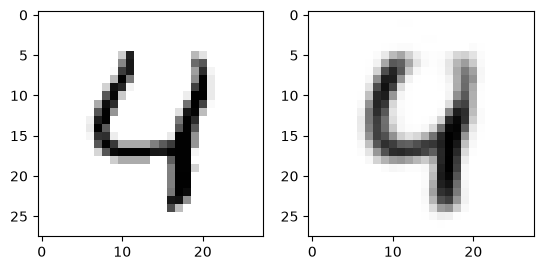

In [1486]:
import matplotlib.pyplot as plt
test = x_test[4]
def view_reconstruction(model, example):
    rc = model.forward(example)
    if isinstance(rc, tuple): 
        rc = rc[0]
    plt.subplot(1, 2, 1)
    plt.imshow(example.reshape(28, 28), cmap="gray_r")
    plt.subplot(1, 2, 2)
    plt.imshow(rc.reshape(28, 28), cmap="gray_r")
    plt.imshow(rc.reshape(28,28), cmap="gray_r");
view_reconstruction(autoencoder, test)